# Skin Lesion Classification using CNN

## Semester Project – Programming for AI

### Team Members
- bscs24043 Ibrahim Butt
- bscs24095 Waize Arif
- bscs24139 Syed Jaffar Raza Kazmi
- bscs24083 Muhammad Moiz

### Objective
Build a Convolutional Neural Network (CNN) model to classify skin lesion images.

# Python Imports

In [1]:
!pip install torchmetrics

import torch
import torchvision
from torch.utils.data import DataLoader
import torchmetrics
from torchmetrics import ConfusionMatrix
import matplotlib.pyplot as plt
import numpy as np
from torch import nn
from timeit import default_timer as timer
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 52.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!cp "/content/drive/MyDrive/skin_lesion/skin_dataset.zip" "/content/"

!unzip -q "/content/skin_dataset.zip" -d "/content/"

!ls "/content/dataset"

acne  bruises  burn  healthy  pigmentation


# Check Version and Device

In [4]:
print(f"PyTorchColab Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

PyTorchColab Version: 2.10.0+cu128
Torchvision Version: 0.25.0+cu128
Using device: cuda


# HyperParameters

In [ ]:
# --- HYPERPARAMETER DASHBOARD ---
# added but unuesd filhaal..

SEED = 42                # seed for reproducibility
BATCH_SIZE = 32          # lower if model getting stuck
LEARNING_RATE = 0.0005   # rate of learning
EPOCHS = 30              # Itterations, more for difficult learning
DROPOUT_RATE = 0.3       # Kills 30% of neurons randomly to stop memorization
IMAGE_SIZE = 224         # image size

# Transformin data

In [5]:
# --- Block 1: DATA TRANSFORMING ---
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomVerticalFlip(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("Transforms defined successfully.")

Transforms defined successfully.


# Data Loading

In [6]:
dataset_path = "/content/dataset"
full_dataset = ImageFolder(root=dataset_path, transform=data_transforms)

# Spliting 80 20 for train and test
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# making loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Successfully loaded {len(full_dataset)} total images.")
print(f"Classes detected: {full_dataset.classes}")

Successfully loaded 687 total images.
Classes detected: ['acne', 'bruises', 'burn', 'healthy', 'pigmentation']


# The CNN class

In [16]:
class SimpleSkinCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, 5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))

        x = x.view(-1, 64 * 28 * 28)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleSkinCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Model architecture built and pushed to GPU.")

Model architecture built and pushed to GPU.


# Training Loop

In [17]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    # Train the model
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f}")

# Test the model immediately after training
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\nFinal Test Accuracy: {100 * correct / total:.2f}%")

Epoch 1/10 | Loss: 1.5690
Epoch 2/10 | Loss: 1.3262
Epoch 3/10 | Loss: 1.0419
Epoch 4/10 | Loss: 0.9202
Epoch 5/10 | Loss: 0.8734
Epoch 6/10 | Loss: 0.6964
Epoch 7/10 | Loss: 0.6838
Epoch 8/10 | Loss: 0.6188
Epoch 9/10 | Loss: 0.6150
Epoch 10/10 | Loss: 0.5521

Final Test Accuracy: 67.39%


# Accuracy and Prediction checking

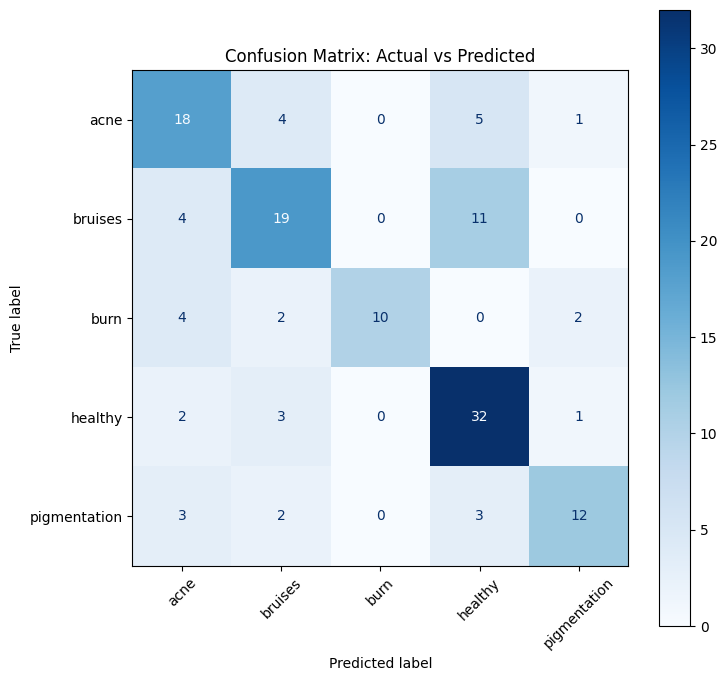

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# predictions and true labels from the test set
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        # Move back to CPU to use with standard Python tools
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# confusion matrix for classification and predictions
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix: Actual vs Predicted")
plt.show()